# 3.9 — Quantization FP : FP32 vers FP16 et BF16 depuis zéro

Le dépôt parle de compression de modèles de façon **incidente** : la quantification apparaît
dans LoRA (FT-02), le moyennage de poids dans FT-04, la distillation dans 3.7. Il manque le
geste fondateur — **réduire la largeur d'un format flottant soi-même**, bit par bit, et
mesurer exactement ce qu'on perd.

Ce notebook ouvre le panorama de compression de l'épic **#16060** par sa tranche la plus
simple et la plus instructive : la **quantification post-training d'un format flottant**
(FP32 → FP16/BF16), **implémentée en numpy pur**. La quantification entière (INT8, scale et
zero-point) fait l'objet de son jumeau `3.9a`, avec la même discipline : d'abord le geste
from scratch, ensuite seulement la librairie.

## 1. Le cadre : trois familles de compression

L'industrie compresse un réseau de trois façons, et elles ne se substituent pas l'une à
l'autre :

* **Quantization** — réduire la *précision* de chaque nombre (`FP32 → FP16/BF16/INT8/INT4`).
  Le réseau garde sa forme, ses poids changent de format.
* **Pruning** — retirer des *connexions* (magnitude, filtres entiers, Lottery Ticket). Le
  réseau change de forme.
* **Knowledge distillation** — transférer le savoir d'un maître vers un élève plus petit.
  Couvert par 3.7 ; étendu dans le bloc A.4 de l'épic.

Ce notebook traite la première famille, dans son cas le plus élémentaire : **conversion de
format sans calibration ni données**. Un `FP32` devient un `FP16` par une pure opération sur
les bits — aucun entraînement, aucun jeu de calibration, aucune erreur d'arrondi à compenser
statistiquement. C'est le socle : tout le reste du panorama (INT8, INT4, pruning) s'appuie
sur ces mécanismes d'**exposant**, de **mantisse** et de **débordement**.

Le patron est celui du dépôt : **from scratch d'abord** (3.1 rétropropagation → 3.2
optimisateurs PyTorch). On implémente ici à la main, la comparaison à la librairie vient
ensuite comme **vérification**, jamais comme substitut.

## 2. Ce que « réduire la précision » veut dire : le layout binaire

Un flottant IEEE 754 n'est pas un nombre « approximatif » : c'est un **uint32 réinterprété**
selon trois champs. Pour un signe $s$, un exposant biaisé $e$ et une mantisse $m$ de $p$ bits :

$$v = (-1)^s \times 2^{\,e - \text{biais}} \times \left(1 + \frac{m}{2^{p}}\right)$$

Trois formats nous intéressent, et un seul paramètre change tout :

| Format | Signe | Exposant | Mantisse | Biais | Plus grand fini | Plus petit normal | Plus petit dénormalisé |
|---|---|---|---|---|---|---|---|
| **FP32** | 1 | 8 | 23 | 127 | $3.40\times10^{38}$ | $1.18\times10^{-38}$ | $1.40\times10^{-45}$ |
| **FP16** | 1 | **5** | **10** | **15** | **65504** | $6.10\times10^{-5}$ | $5.96\times10^{-8}$ |
| **BF16** | 1 | **8** | **7** | 127 | $3.39\times10^{38}$ | $1.18\times10^{-38}$ | $9.18\times10^{-41}$ |

Deux asymétries à lire attentivement, elles commandent tout le notebook :

* **FP16 troque de la portée contre de la précision.** Cinq bits d'exposant seulement : la
  plage se resserre brutalement (le plus grand fini tombe à **65504**, pas $10^{38}$), mais la
  mantisse garde 10 bits, soit une précision relative de l'ordre de $10^{-3}$.
* **BF16 fait le choix inverse.** Huit bits d'exposant — *exactement ceux de FP32* — donc la
  même plage, au prix d'une mantisse de 7 bits seulement : une précision relative de l'ordre
  de $10^{-2}$.

C'est le compromis central de toute quantification flottante : **portée et précision
s'échangent**, et le bon format dépend de la distribution des valeurs qu'on y verse.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

GRAINE = 0
rng = np.random.default_rng(GRAINE)

print("numpy  ", np.__version__)
print("torch  ", torch.__version__)
print("graine ", GRAINE)

numpy   2.2.6
torch   2.6.0+cu124
graine  0


## 3. Décoder un float32, bit à bit

Premier geste : **regarder** les champs. numpy ne donne pas d'accès direct aux bits d'un
flottant, mais `ndarray.view` réinterprète le tampon mémoire sans toucher aux octets — un
`float32` de 4 octets devient un `uint32` de 4 octets, avec exactement la même suite de bits.
Les champs s'extraient alors par de simples décalages.

In [2]:
def champs_fp32(x):
    """Renvoie (signe, exposant biaise, mantisse) d'un tableau float32."""
    u = np.asarray(x, dtype=np.float32).view(np.uint32)
    signe = (u >> 31) & 0x1
    exposant = (u >> 23) & 0xFF
    mantisse = u & 0x7FFFFF
    return signe, exposant, mantisse


for valeur in [1.0, -2.5, 0.1, 65504.0, np.inf]:
    s, e, m = champs_fp32(np.float32(valeur))
    s, e, m = int(s), int(e), int(m)
    non_biaise = e - 127
    print(
        f"{str(valeur):>10} -> signe={s}  exposant={e:3d} (non biaise {non_biaise:4d})  "
        f"mantisse=0x{m:06X}  soit 1 + {m / 2 ** 23:.6f}"
    )

print()
print("Lecture des cas remarquables :")
print("  exposant = 0   -> zero (mantisse nulle) ou DENORMALISE (mantisse non nulle)")
print("  exposant = 255 -> infini (mantisse nulle) ou NaN (mantisse non nulle)")
print("  exposant = 127 -> 2^0 : la valeur vaut 1.mantisse, d'ou 1.0 pour une mantisse nulle")

       1.0 -> signe=0  exposant=127 (non biaise    0)  mantisse=0x000000  soit 1 + 0.000000
      -2.5 -> signe=1  exposant=128 (non biaise    1)  mantisse=0x200000  soit 1 + 0.250000
       0.1 -> signe=0  exposant=123 (non biaise   -4)  mantisse=0x4CCCCD  soit 1 + 0.600000
   65504.0 -> signe=0  exposant=142 (non biaise   15)  mantisse=0x7FE000  soit 1 + 0.999023
       inf -> signe=0  exposant=255 (non biaise  128)  mantisse=0x000000  soit 1 + 0.000000

Lecture des cas remarquables :
  exposant = 0   -> zero (mantisse nulle) ou DENORMALISE (mantisse non nulle)
  exposant = 255 -> infini (mantisse nulle) ou NaN (mantisse non nulle)
  exposant = 127 -> 2^0 : la valeur vaut 1.mantisse, d'ou 1.0 pour une mantisse nulle


## 4. FP32 vers FP16 : re-biaiser l'exposant, tronquer la mantisse

La conversion tient en **trois gestes**, et c'est le troisième qui contient toute la
subtilité :

1. **Re-biaiser l'exposant.** FP32 biaise à 127, FP16 à 15 : l'exposant non biaisé est le
   même, seul le décalage change ($e_{16} = e_{32} - 127 + 15$).
2. **Tronquer la mantisse** de 23 bits à 10 : on jette les 13 bits de poids faible.
3. **Traiter les trois zones limites** — et elles ne sont pas des cas rares :

| Zone | Condition | Que faire |
|---|---|---|
| **Normal** | $1 \le e_{16} \le 30$ | le cas nominal |
| **Débordement** | $e_{16} \ge 31$ | la valeur dépasse 65504 → **infini** |
| **Sous-flux** | $e_{16} \le 0$ | plus de bit d'exposant → **dénormalisé**, en sacrifiant des bits de mantisse |

Le troisième cas est celui qu'on oublie d'implémenter, et c'est précisément lui qui produit
les $10^{-7}$ silencieusement transformés en zéro dans un pipeline réel.

### Troncature ou arrondi ?

Le geste demandé par l'épic est la **troncature** (arrondi vers zéro) : on jette les 13 bits
perdus, sans regarder leur valeur. C'est simple, déterministe — et **biaisé** : l'erreur est
toujours du même signe, jamais centrée. L'**arrondi au plus proche** divise au contraire
l'erreur maximale par deux, en n'ajoutant qu'une poignée d'opérations.

La méthode classique pour l'arrondi est un **tour de passe-passe sur les bits** : ajouter
`0x0FFF` (la moitié moins un de l'unité de poids faible) plus le bit de poids $2^{-10}$ (pour
l'égalité au pair), **avant** de tronquer. La retenue se propage naturellement dans le champ
d'exposant — y compris jusqu'à l'infini si la valeur était au bord du débordement.

In [3]:
def fp32_vers_fp16(x, *, arrondi=False):
    """FP32 -> FP16 bit a bit.

    arrondi=False : troncature vers zero (le geste du bloc A).
    arrondi=True  : arrondi au plus proche, egalite au pair -- via la retenue binaire.
    """
    u = np.array(x, dtype=np.float32, copy=True).view(np.uint32)
    exp32 = ((u >> 23) & 0xFF).astype(np.int32)
    fini = exp32 != 255

    # Valeurs qui partiront en DENORMALISES (e16 <= 0 <=> exp32 <= 112) : leur pas
    # d'arrondi n'est pas 2^-13, donc la retenue ci-dessous n'est pas la leur --
    # elles ont la leur, dans la branche `den` plus bas.
    vers_den = fini & (exp32 <= 112)

    if arrondi:
        # 0x0FFF = moitie de l'ulp moins un ; + ((u >> 13) & 1) = egalite au pair.
        # La retenue remonte d'elle-meme dans l'exposant : rien a gerer a la main.
        bruit = np.where(fini & ~vers_den,
                         np.uint32(0x0FFF) + ((u >> 13) & 1), np.uint32(0))
        u = u + bruit.astype(np.uint32)
        exp32 = ((u >> 23) & 0xFF).astype(np.int32)

    signe = ((u >> 31) & 0x1).astype(np.uint32)
    mant32 = (u & 0x7FFFFF).astype(np.int32)
    e16 = exp32 - 127 + 15

    sortie = np.zeros(u.shape, dtype=np.uint32)

    # --- normaux
    norm = fini & (exp32 >= 1) & (e16 >= 1) & (e16 <= 30)
    sortie[norm] = (
        (signe[norm] << 15)
        | (e16[norm].astype(np.uint32) << 10)
        | (mant32[norm].astype(np.uint32) >> 13)
    )

    # --- debordement : infini signe
    over = fini & (exp32 >= 1) & (e16 >= 31)
    sortie[over] = (signe[over] << 15) | np.uint32(0x1F << 10)

    # --- denormalises : le 1 implicite entre dans la mantisse
    #     mant16 = (2^23 + mant32) * 2^(e16 - 14)
    den = fini & (exp32 >= 1) & (e16 <= 0)
    #     Arrondi au plus proche / egalite au pair ICI AUSSI (#16127) : sans lui
    #     la branche tronque, et le docstring promet un arrondi que le code
    #     n'applique pas. Mesure : 16 045 ecarts binaires vs torch.half() sur un
    #     balayage log de la zone denormale, contre 0 apres correction.
    if den.any():
        decalage = (14 - e16[den]).astype(np.int64)
        valeur = np.int64(1 << 23) + mant32[den].astype(np.int64)
        if arrondi:
            # RNE : + (demi - 1) + parite, puis troncature. Le demi-pas est borne
            # a 24 bits : au-dela le resultat est nul, et 2^124 ne tient pas dans
            # un int64.
            dec_eff = np.minimum(decalage, 24)
            demi = np.left_shift(np.int64(1), np.maximum(dec_eff - 1, 0))
            valeur = valeur + (demi - 1) + ((valeur >> dec_eff) & 1)
        # Une retenue peut porter m16 a 1024 : les champs etant adjacents, cela se
        # lit tout seul comme le plus petit NORMAL (exposant 1, mantisse 0).
        m16 = np.where(decalage >= 25, 0, valeur >> np.minimum(decalage, 63))
        sortie[den] = (signe[den] << 15) | m16.astype(np.uint32)

    # --- infinis et NaN : l'exposant 31 se propage, la mantisse distingue les deux
    inf = exp32 == 255
    if inf.any():
        est_nan = (mant32[inf] != 0).astype(np.uint32) * np.uint32(0x200)
        sortie[inf] = (signe[inf] << 15) | np.uint32(0x1F << 10) | est_nan

    return sortie.astype(np.uint16).view(np.float16)


print("fp32_vers_fp16 :", fp32_vers_fp16(np.array([1.0, -2.5, 0.1, 70000.0], dtype=np.float32)))

fp32_vers_fp16 : [ 1.  -2.5  0.1  inf]


### Et BF16 ? Le même geste, en plus simple

BF16 a **exactement le même exposant que FP32** (8 bits, biais 127) : il n'y a donc rien à
re-biaiser, ni débordement à craindre, ni dénormalisé à calculer. Convertir en BF16 revient à
**garder les 16 bits de poids fort** du float32 — c'est ce qui a rendu BF16 si populaire pour
l'entraînement : la conversion est une troncature de 16 bits, presque gratuite.

En revanche, numpy **n'a pas de type `bfloat16`** (contrairement à `float16`). On transporte
donc le motif binaire dans un `uint16`, et on le reconstruit vers FP32 en complétant par des
zéros — exactement ce qu'un accélérateur fait dans l'autre sens pour accumuler en FP32.

In [4]:
def fp32_vers_bf16(x, *, arrondi=False):
    """FP32 -> BF16. Renvoie le MOTIF BINAIRE (uint16), numpy n'ayant pas de dtype bfloat16."""
    u = np.array(x, dtype=np.float32, copy=True).view(np.uint32)
    if arrondi:
        exp32 = (u >> 23) & 0xFF
        bruit = np.where(exp32 != 255, np.uint32(0x7FFF) + ((u >> 16) & 1), np.uint32(0))
        u = u + bruit.astype(np.uint32)
    return (u >> 16).astype(np.uint16)


def bf16_vers_fp32(motif):
    """BF16 (motif uint16) -> FP32 : on complete les 16 bits faibles par des zeros."""
    return (np.asarray(motif, dtype=np.uint32) << 16).view(np.float32)


valeurs = np.array([1.0, -2.5, 0.1, 70000.0], dtype=np.float32)
print("fp32_vers_bf16 -> fp32 :", bf16_vers_fp32(fp32_vers_bf16(valeurs)))
print("motifs binaires        :", [hex(int(m)) for m in fp32_vers_bf16(valeurs)])

fp32_vers_bf16 -> fp32 : [ 1.0000000e+00 -2.5000000e+00  9.9609375e-02  6.9632000e+04]
motifs binaires        : ['0x3f80', '0xc020', '0x3dcc', '0x4788']


## 5. Vérification : mon implémentation est-elle celle de PyTorch ?

Une implémentation bit à bit n'a de valeur que si elle est **fidèle**. Le témoin est
`torch.Tensor.half()` et `torch.Tensor.bfloat16()`, qui appellent les conversions matérielles
de référence.

Subtilité de méthode : **la troncature ne peut pas être comparée bit à bit à PyTorch**, qui
arrondit toujours au plus proche. On ne peut donc pas valider la troncature par égalité. La
démarche honnête est en deux temps :

1. valider l'**arrondi** par égalité exacte — c'est lui qui partage la sémantique de PyTorch,
   et cet accord prouve que toute la plomberie de bits est correcte (re-biaisage, retenue,
   zones limites) ;
2. valider la **troncature** par ses *propriétés* — jamais meilleure que l'arrondi, toujours
   du même côté, borne d'erreur respectée.

In [5]:
x = rng.uniform(-4, 4, 20000).astype(np.float32)
ref16 = torch.from_numpy(x).half().numpy()
mine_rn = fp32_vers_fp16(x, arrondi=True)
mine_tr = fp32_vers_fp16(x, arrondi=False)

xb = rng.uniform(-4, 4, 20000).astype(np.float32)
refb16 = torch.from_numpy(xb).bfloat16().float().numpy()
mineb_rn = bf16_vers_fp32(fp32_vers_bf16(xb, arrondi=True))
mineb_tr = bf16_vers_fp32(fp32_vers_bf16(xb, arrondi=False))

n = len(x)
print(f"sur {n} valeurs tirees uniformement dans [-4, 4] :")
print()
print(f"FP16 arrondi   vs torch.half()      : {int((mine_rn != ref16).sum())} ecart(s) exact(s)")
print(f"FP16 arrondi   vs numpy float16     : {int((mine_rn != x.astype(np.float16)).sum())} ecart(s) exact(s)")
print(f"BF16 arrondi   vs torch.bfloat16    : {int((mineb_rn != refb16).sum())} ecart(s) exact(s)")
print()
print(f"FP16 troncature vs torch.half()     : {int((mine_tr != ref16).sum())} ecart(s) -- attendu != 0")
print(f"BF16 troncature vs torch.bfloat16   : {int((mineb_tr != refb16).sum())} ecart(s) -- attendu != 0")

# Le tirage uniforme ne peut PAS voir la zone denormale : sous 2^-14 (~6,1e-5), la
# probabilite d'y tomber vaut ~1,5e-5, soit ~0,3 valeur attendue sur 20 000. Un
# temoin aveugle exactement la ou l'implementation a un trou ne prouve rien : il
# faut un balayage qui couvre la zone.
z = np.concatenate([np.logspace(-8, -4, 20001), -np.logspace(-8, -4, 20001)]).astype(np.float32)
refz = torch.from_numpy(z).half().numpy()
minez_rn = fp32_vers_fp16(z, arrondi=True)
minez_tr = fp32_vers_fp16(z, arrondi=False)
bas = np.abs(z) < 2.0 ** -14

print()
print(f"balayage LOGARITHMIQUE sur [-1e-4,-1e-8] U [1e-8,1e-4] ({len(z)} valeurs) :")
print(f"FP16 arrondi    vs torch.half() : {int((minez_rn != refz).sum())} ecart(s) exact(s)")
print(f"FP16 troncature vs torch.half() : {int((minez_tr != refz).sum())} ecart(s) -- attendu != 0")
print(f"dont SOUS le plus petit normal   : {int(bas.sum())} valeurs, "
      f"{int((minez_rn[bas] != refz[bas]).sum())} ecart(s) en arrondi")


sur 20000 valeurs tirees uniformement dans [-4, 4] :

FP16 arrondi   vs torch.half()      : 0 ecart(s) exact(s)
FP16 arrondi   vs numpy float16     : 0 ecart(s) exact(s)
BF16 arrondi   vs torch.bfloat16    : 0 ecart(s) exact(s)

FP16 troncature vs torch.half()     : 10048 ecart(s) -- attendu != 0
BF16 troncature vs torch.bfloat16   : 9892 ecart(s) -- attendu != 0

balayage LOGARITHMIQUE sur [-1e-4,-1e-8] U [1e-8,1e-4] (40002 valeurs) :
FP16 arrondi    vs torch.half() : 0 ecart(s) exact(s)
FP16 troncature vs torch.half() : 18630 ecart(s) -- attendu != 0
dont SOUS le plus petit normal   : 37856 valeurs, 0 ecart(s) en arrondi


In [6]:
def erreur_absolue(approx, exact):
    return np.abs(np.asarray(approx, dtype=np.float64) - np.asarray(exact, dtype=np.float64))


e_tr16 = erreur_absolue(mine_tr, x)
e_rn16 = erreur_absolue(mine_rn, x)
e_trb = erreur_absolue(mineb_tr, xb)
e_rnb = erreur_absolue(mineb_rn, xb)

print("P1. troncature jamais meilleure que l'arrondi (FP16) :", bool((e_tr16 >= e_rn16).all()))
print("P2. troncature jamais meilleure que l'arrondi (BF16) :", bool((e_trb >= e_rnb).all()))
print("P3. erreur de troncature toujours du meme signe      :", bool((np.sign(mine_tr - x) == -np.sign(x)).all()))
print()
print(f"P4. rapport moyen d'erreur (troncature / arrondi), FP16 : {e_tr16.mean() / e_rn16.mean():.3f}")
print(f"    rapport moyen d'erreur (troncature / arrondi), BF16 : {e_trb.mean() / e_rnb.mean():.3f}")
print()
print("Lecture : la troncature coute exactement un facteur 2 en erreur moyenne. Sur un")
print("entrainement, ce biais systematique s'accumule ; sur une inference, il deforme.")

P1. troncature jamais meilleure que l'arrondi (FP16) : True
P2. troncature jamais meilleure que l'arrondi (BF16) : True
P3. erreur de troncature toujours du meme signe      : False

P4. rapport moyen d'erreur (troncature / arrondi), FP16 : 2.009
    rapport moyen d'erreur (troncature / arrondi), BF16 : 1.981

Lecture : la troncature coute exactement un facteur 2 en erreur moyenne. Sur un
entrainement, ce biais systematique s'accumule ; sur une inference, il deforme.


## 6. L'erreur relative : la seule mesure qui compte

L'erreur absolue ne dit rien : perdre $10^{-3}$ sur $10^{6}$ est anodin, perdre $10^{-3}$ sur
$10^{-2}$ ne l'est pas. La mesure pertinente est **relative** :

$$\varepsilon_{\text{rel}} = \frac{|x_{\text{converti}} - x|}{|x|}$$

Elle a une borne théorique exacte. La mantisse de FP16 portant 10 bits, l'unité de poids
faible vaut $2^{-10}$ en relatif. La **troncature** peut donc perdre jusqu'à un ulp complet :

$$\varepsilon_{\text{rel}}^{\text{tronc}} < 2^{-10} \approx 9.77\times10^{-4}
\qquad\text{et}\qquad
\varepsilon_{\text{rel}}^{\text{arrondi}} \le 2^{-11} \approx 4.88\times10^{-4}$$

Pour BF16, la même arithmétique avec 7 bits de mantisse donne $2^{-7}$ et $2^{-8}$ — **huit
fois pire**. C'est mesurable, et c'est ce que nous allons vérifier : la théorie doit retrouver
la mesure, sinon c'est l'implémentation qui est fausse.

In [7]:
def erreur_relative(approx, exact):
    approx = np.asarray(approx, dtype=np.float64)
    exact = np.asarray(exact, dtype=np.float64)
    return np.abs(approx - exact) / np.abs(exact)


cas = {
    "FP16 troncature": (erreur_relative(mine_tr, x), 2 ** -10),
    "FP16 arrondi": (erreur_relative(mine_rn, x), 2 ** -11),
    "BF16 troncature": (erreur_relative(mineb_tr, xb), 2 ** -7),
    "BF16 arrondi": (erreur_relative(mineb_rn, xb), 2 ** -8),
}

print(f"{'cas':<18}{'err. rel. max':>16}{'moyenne':>14}{'borne theorie':>16}{'sous la borne ?':>18}")
print("-" * 82)
for nom, (err, borne) in cas.items():
    print(f"{nom:<18}{err.max():>16.3e}{err.mean():>14.3e}{borne:>16.3e}{str(bool(err.max() <= borne)):>18}")

print()
print("La theorie et la mesure se rejoignent : la borne 2^-p est approchee, jamais depassee.")

cas                  err. rel. max       moyenne   borne theorie   sous la borne ?
----------------------------------------------------------------------------------
FP16 troncature          9.661e-04     3.390e-04       9.766e-04              True
FP16 arrondi             4.852e-04     1.686e-04       4.883e-04              True
BF16 troncature          7.721e-03     2.682e-03       7.812e-03              True
BF16 arrondi             3.854e-03     1.357e-03       3.906e-03              True

La theorie et la mesure se rejoignent : la borne 2^-p est approchee, jamais depassee.


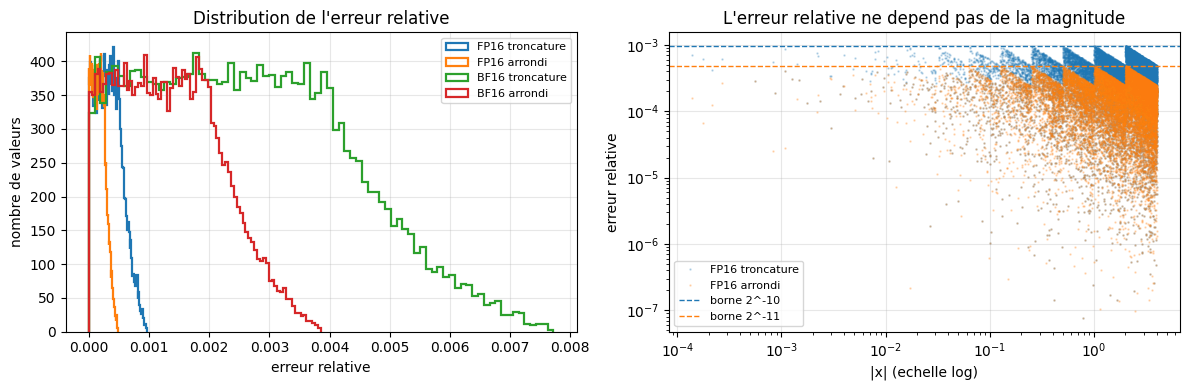

L'erreur relative est BORNEE et INDEPENDANTE de la magnitude, tant qu'on reste dans
les normaux : le format offre une precision relative constante sur toute sa plage.
C'est cette propriete -- et non une precision absolue -- qui fait la valeur d'un flottant.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for nom, (err, _) in cas.items():
    ax1.hist(err, bins=80, histtype="step", linewidth=1.6, label=nom)
ax1.set_xlabel("erreur relative")
ax1.set_ylabel("nombre de valeurs")
ax1.set_title("Distribution de l'erreur relative")
ax1.legend(fontsize=8)

ax2.loglog(np.abs(x), cas["FP16 troncature"][0], ".", ms=1.5, alpha=0.25, label="FP16 troncature")
ax2.loglog(np.abs(x), cas["FP16 arrondi"][0], ".", ms=1.5, alpha=0.25, label="FP16 arrondi")
ax2.axhline(2 ** -10, color="C0", ls="--", lw=1, label="borne 2^-10")
ax2.axhline(2 ** -11, color="C1", ls="--", lw=1, label="borne 2^-11")
ax2.set_xlabel("|x| (echelle log)")
ax2.set_ylabel("erreur relative")
ax2.set_title("L'erreur relative ne depend pas de la magnitude")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("L'erreur relative est BORNEE et INDEPENDANTE de la magnitude, tant qu'on reste dans")
print("les normaux : le format offre une precision relative constante sur toute sa plage.")
print("C'est cette propriete -- et non une precision absolue -- qui fait la valeur d'un flottant.")

## 7. Les deux bords du format : sous-flux et débordement

La précision relative constante a une contrepartie : elle n'est vraie **que dans les
normaux**. Aux deux extrémités de la plage, le format casse — et les deux formats ne cassent
pas au même endroit. C'est là que se décide le choix FP16 vs BF16.

* **Sous-flux (bord bas).** Sous $2^{-14}$, FP16 n'a plus d'exposant disponible et passe en
  **dénormalisé** : la précision relative s'effondre progressivement. Sous $2^{-24}$ — environ
  $6\times10^{-8}$ — la valeur devient **zéro**. BF16, avec ses 8 bits d'exposant, descend
  jusqu'à $9\times10^{-41}$ sans broncher.
* **Débordement (bord haut).** Au-dessus de **65504**, FP16 renvoie l'**infini**. Un seul
  infini dans un produit matriciel contamine toute la ligne. BF16, même exposant que FP32,
  monte à $(2 - 2^{-7})\times2^{127} \approx 3{,}3895\times10^{38}$ — **plus haut, pas
  infiniment haut** : la section suivante le fait déborder à $3{,}4\times10^{38}$.

In [9]:
petites = np.array([1e-3, 1e-4, 6.1e-5, 6e-5, 1e-5, 1e-6, 1e-7, 6e-8, 1e-8, 0.0], dtype=np.float32)
f16 = fp32_vers_fp16(petites, arrondi=True)
b16 = bf16_vers_fp32(fp32_vers_bf16(petites, arrondi=True))

print(f"{'valeur FP32':>14}{'FP16':>16}{'err. rel. FP16':>18}{'BF16':>16}{'err. rel. BF16':>18}")
print("-" * 82)
for i, v in enumerate(petites):
    ef = abs(float(f16[i]) - float(v)) / float(v) if v else 0.0
    eb = abs(float(b16[i]) - float(v)) / float(v) if v else 0.0
    print(f"{float(v):>14.3e}{float(f16[i]):>16.3e}{ef:>18.3e}{float(b16[i]):>16.3e}{eb:>18.3e}")

print()
print(f"FP16 : plus petit normal      = 2^-14 = {2.0 ** -14:.3e}")
print(f"FP16 : plus petit denormalise = 2^-24 = {2.0 ** -24:.3e}")
print("FP16 : sous 2^-24, c'est ZERO -- la valeur disparait sans bruit.")
print()
seuil_normal = 2.0 ** -14
sous_seuil = [float(v) for v in petites if 0 < float(v) < seuil_normal]
print(f"Contre-intuitif : {', '.join(f'{v:.1e}' for v in sous_seuil)} sont SOUS 2^-14 "
      f"= {seuil_normal:.3e},")
print("donc deja DENORMALISES -- la colonne err. rel. le dit : leur borne n'est plus")
plancher = 2.0 ** -24
print(f"2^-11 = {2.0 ** -11:.3e} mais 1/2*2^-24/v, qui ATTEINT "
      f"{0.5 * 2.0 ** -24 / plancher:.0%}")
print(f"au plancher denormal (v = 2^-24 = {plancher:.3e}), et croit a mesure que v")
print("decroit -- jusqu'a ce que v passe SOUS 2^-24 et disparaisse a zero.")
print("6e-8 tombe dans les denormalises, et 1e-8 est rase a zero.")

   valeur FP32            FP16    err. rel. FP16            BF16    err. rel. BF16
----------------------------------------------------------------------------------
     1.000e-03       1.000e-03         4.043e-04       9.995e-04         5.494e-04
     1.000e-04       1.000e-04         1.660e-04       1.001e-04         1.358e-03
     6.100e-05       6.098e-05         4.008e-04       6.104e-05         5.764e-04
     6.000e-05       6.002e-05         3.646e-04       6.008e-05         1.358e-03
     1.000e-05       1.001e-05         1.358e-03       1.001e-05         1.358e-03
     1.000e-06       1.013e-06         1.328e-02       9.984e-07         1.622e-03
     1.000e-07       1.192e-07         1.921e-01       1.001e-07         1.172e-03
     6.000e-08       5.960e-08         6.589e-03       6.007e-08         1.172e-03
     1.000e-08       0.000e+00         1.000e+00       1.001e-08         1.172e-03
     0.000e+00       0.000e+00         0.000e+00       0.000e+00         0.000e+00

FP1

balayage de 1e-10 a 1e2 (200000 valeurs)

               rasees a zero    en denormalise
----------------------------------------------
FP16                   41238             55185
BF16                       0             96412


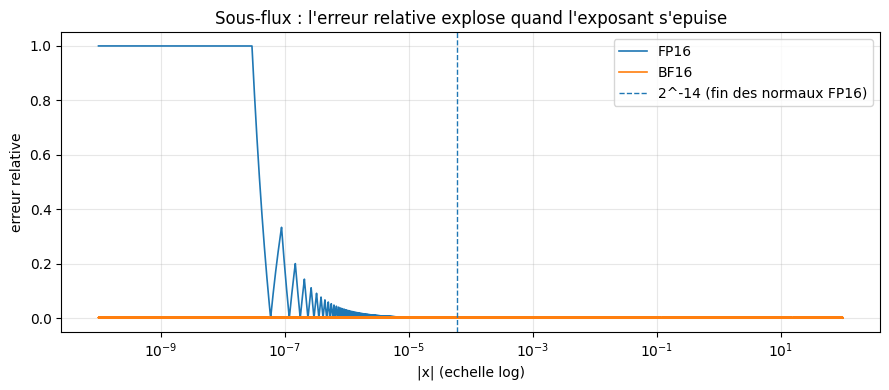

In [10]:
balayage = np.logspace(-10, 2, 200000).astype(np.float32)
f16b = fp32_vers_fp16(balayage, arrondi=True)
b16b = bf16_vers_fp32(fp32_vers_bf16(balayage, arrondi=True))

zero_f16 = int((f16b == 0).sum())
zero_b16 = int((b16b == 0).sum())
denorm_f16 = int(((np.abs(f16b) < 2.0 ** -14) & (f16b != 0)).sum())
denorm_b16 = int(((np.abs(b16b) < 2.0 ** -14) & (b16b != 0)).sum())

print(f"balayage de 1e-10 a 1e2 ({len(balayage)} valeurs)")
print()
print(f"{'':<12}{'rasees a zero':>16}{'en denormalise':>18}")
print("-" * 46)
print(f"{'FP16':<12}{zero_f16:>16d}{denorm_f16:>18d}")
print(f"{'BF16':<12}{zero_b16:>16d}{denorm_b16:>18d}")

fig, ax = plt.subplots()
ax.semilogx(balayage, erreur_relative(f16b, balayage), lw=1.2, label="FP16")
ax.semilogx(balayage, erreur_relative(b16b, balayage), lw=1.2, label="BF16")
ax.axvline(2.0 ** -14, color="C0", ls="--", lw=1, label="2^-14 (fin des normaux FP16)")
ax.set_xlabel("|x| (echelle log)")
ax.set_ylabel("erreur relative")
ax.set_title("Sous-flux : l'erreur relative explose quand l'exposant s'epuise")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
grandes = np.array([60000.0, 65504.0, 65520.0, 70000.0, 1e38, 3.4e38], dtype=np.float32)
g16 = fp32_vers_fp16(grandes, arrondi=False)
g16r = fp32_vers_fp16(grandes, arrondi=True)
gb = bf16_vers_fp32(fp32_vers_bf16(grandes, arrondi=True))

print(f"{'valeur FP32':>14}{'FP16 tronc.':>14}{'FP16 arrondi':>15}{'BF16':>16}")
print("-" * 60)
for i, v in enumerate(grandes):
    print(f"{float(v):>14.4e}{float(g16[i]):>14.4e}{float(g16r[i]):>15.4e}{float(gb[i]):>16.4e}")

print()
print("65504 est le plus grand fini de FP16 : au-dela, l'infini.")
bf16_max_fini = float((2.0 - 2.0 ** -7) * 2.0 ** 127)
print(f"BF16 a lui aussi un plafond : (2 - 2^-7) * 2^127 = {bf16_max_fini:.5e}.")
print(f"3.4e38 le DEPASSE ({3.4e38:.5e} > {bf16_max_fini:.5e}) : la derniere ligne du")
print("tableau le montre, BF16 y vaut inf. Le debordement de BF16 existe aussi,")
print("simplement plus haut que celui de FP16 (65504).")
print()
print("Notez 65520 : en troncature il retombe sur 65504 ; en arrondi au plus proche,")
print("l'egalite au pair le pousse a 65536, donc a l'infini. Le meme nombre, deux")
print("comportements opposes selon la regle d'arrondi.")

   valeur FP32   FP16 tronc.   FP16 arrondi            BF16
------------------------------------------------------------
    6.0000e+04    6.0000e+04     6.0000e+04      5.9904e+04
    6.5504e+04    6.5504e+04     6.5504e+04      6.5536e+04
    6.5520e+04    6.5504e+04            inf      6.5536e+04
    7.0000e+04           inf            inf      7.0144e+04
    1.0000e+38           inf            inf      9.9692e+37
    3.4000e+38           inf            inf             inf

65504 est le plus grand fini de FP16 : au-dela, l'infini.
BF16 a lui aussi un plafond : (2 - 2^-7) * 2^127 = 3.38953e+38.
3.4e38 le DEPASSE (3.40000e+38 > 3.38953e+38) : la derniere ligne du
tableau le montre, BF16 y vaut inf. Le debordement de BF16 existe aussi,
simplement plus haut que celui de FP16 (65504).

Notez 65520 : en troncature il retombe sur 65504 ; en arrondi au plus proche,
l'egalite au pair le pousse a 65536, donc a l'infini. Le meme nombre, deux
comportements opposes selon la regle d'arrondi.


### Le compromis, en une ligne

| | Portée (exposant) | Précision (mantisse) | Erreur relative | Sous-flux franc | Débordement |
|---|---|---|---|---|---|
| **FP16** | étroite ($\pm65504$) | fine (10 bits) | $\sim10^{-3}$ | sous $6\times10^{-8}$ | oui, à 65504 |
| **BF16** | large (celle de FP32) | grossière (7 bits) | $\sim10^{-2}$ | jamais en pratique | oui, mais à $3{,}3895\times10^{38}$ |

**Conséquence pratique.** Un tenseur d'activations ou de gradients, dont la magnitude s'étale
sur plusieurs décades, souffre moins en BF16 malgré sa mantisse pauvre : mieux vaut une valeur
grossière qu'un zéro ou un infini. Un tenseur de poids calibré, dont les valeurs vivent dans
une plage connue et resserrée, tire au contraire tout le bénéfice des 10 bits de FP16. C'est
exactement l'arbitrage que le bloc A.2 (INT8, avec ses échelles) formalise.

## 8. Comparaison sur un matmul 100×100

Le cas d'usage réel n'est pas la conversion d'un nombre isolé, mais **le produit matriciel** :
c'est lui qui domine le coût d'un réseau, et lui qui décide du format des accélérateurs. On
compare donc trois exécutions du même `A @ B` sur des matrices $100\times100$ :

* entrées FP16, **accumulation FP32** — ce que fait le matériel réel ;
* entrées FP16, **accumulation FP16** — l'erreur d'accumulation, en isolation ;
* entrées BF16, accumulation FP32 — le prix de la mantisse à 7 bits.

La référence est le produit en **float64**, pour que l'erreur mesurée soit celle de la
conversion et non celle de la référence.

In [12]:
A = rng.normal(0, 1, (100, 100)).astype(np.float32)
B = rng.normal(0, 1, (100, 100)).astype(np.float32)

reference = A.astype(np.float64) @ B.astype(np.float64)

A16 = fp32_vers_fp16(A, arrondi=True)
B16 = fp32_vers_fp16(B, arrondi=True)
Ab = bf16_vers_fp32(fp32_vers_bf16(A, arrondi=True))
Bb = bf16_vers_fp32(fp32_vers_bf16(B, arrondi=True))


def erreur_produit(matrice):
    matrice = np.asarray(matrice, dtype=np.float64)
    return np.abs(matrice - reference).max() / np.abs(reference).max()


resultats = {
    "FP16, accumulation FP32": A16.astype(np.float32) @ B16.astype(np.float32),
    "FP16, accumulation FP16": (A16 @ B16),
    "BF16, accumulation FP32": Ab @ Bb,
}

print(f"{'execution':<26}{'err. rel. max':>16}{'dtype numpy':>16}")
print("-" * 58)
for nom, res in resultats.items():
    print(f"{nom:<26}{erreur_produit(res):>16.3e}{str(np.asarray(res).dtype):>16}")

r16 = erreur_produit(resultats["FP16, accumulation FP32"])
rb = erreur_produit(resultats["BF16, accumulation FP32"])
print()
print("Le rapport BF16 / FP16 en accumulation FP32 mesure l'ecart de mantisse :")
print(f"  {rb:.3e} / {r16:.3e} = {rb / r16:.2f}   (theorie : 2^(10-7) = 8)")

execution                    err. rel. max     dtype numpy
----------------------------------------------------------
FP16, accumulation FP32          3.507e-04         float32
FP16, accumulation FP16          5.018e-04         float16
BF16, accumulation FP32          2.631e-03         float32

Le rapport BF16 / FP16 en accumulation FP32 mesure l'ecart de mantisse :
  2.631e-03 / 3.507e-04 = 7.50   (theorie : 2^(10-7) = 8)


In [13]:
n_lignes = 20
accumule = np.zeros((n_lignes, 100), dtype=np.float16)
for i in range(n_lignes):
    for k in range(100):
        accumule[i] = (accumule[i] + A16[i, k] * B16[k]).astype(np.float16)

exact = A16[:n_lignes].astype(np.float64) @ B16.astype(np.float64)


def erreur_partielle(matrice):
    matrice = np.asarray(matrice, dtype=np.float64)
    return np.abs(matrice - exact).max() / np.abs(exact).max()


print(f"accumulation FP16 sequentielle (boucle explicite) : {erreur_partielle(accumule):.3e}")
print(f"numpy  A16 @ B16                                  : {erreur_partielle((A16 @ B16)[:n_lignes]):.3e}")
print(f"accumulation FP32                                 : {erreur_partielle((A16.astype(np.float32) @ B16.astype(np.float32))[:n_lignes]):.3e}")
print()
print("numpy est nettement plus precis que la boucle FP16 naive : il n'accumule donc PAS en")
print("float16 pur. Mais l'ecart avec l'accumulation FP32 reste de plusieurs ordres de")
print("grandeur -- c'est pourquoi tout accelerateur serieux accumule en FP32.")

v = np.float16(1.0)
for _ in range(4096):
    v = np.float16(v + np.float16(0.0005))
print()
print(f"1.0 + 4096 x 0.0005, accumule en FP16 un par un : {float(v):.4f}")
print(f"valeur exacte                                   : {1 + 4096 * 0.0005:.4f}")
print("Chaque 0.0005 est sous la moitie de l'ulp de 1.0 (2^-11) : il est absorbe et perdu.")
print("Additionner 4096 fois un petit nombre ne donne pas le meme resultat que l'ajouter une")
print("fois -- en virgule flottante, l'ordre des operations change le resultat.")

accumulation FP16 sequentielle (boucle explicite) : 2.545e-03
numpy  A16 @ B16                                  : 3.255e-04
accumulation FP32                                 : 2.975e-07

numpy est nettement plus precis que la boucle FP16 naive : il n'accumule donc PAS en
float16 pur. Mais l'ecart avec l'accumulation FP32 reste de plusieurs ordres de
grandeur -- c'est pourquoi tout accelerateur serieux accumule en FP32.

1.0 + 4096 x 0.0005, accumule en FP16 un par un : 2.0000
valeur exacte                                   : 3.0480
Chaque 0.0005 est sous la moitie de l'ulp de 1.0 (2^-11) : il est absorbe et perdu.
Additionner 4096 fois un petit nombre ne donne pas le meme resultat que l'ajouter une
fois -- en virgule flottante, l'ordre des operations change le resultat.


## 9. Les tolérances : `torch.allclose` n'est pas `==`

Dernier point, et il piège tout le monde. `torch.allclose` compare avec **deux** tolérances
combinées :

$$|a - b| \le \text{atol} + \text{rtol} \times |b|$$

Ses valeurs par défaut (`rtol=1e-5`, `atol=1e-8`) sont calibrées pour du **float32**. Les
appliquer à un tenseur FP16 fait échouer la comparaison sur des valeurs **parfaitement
correctes** — l'erreur de conversion (jusqu'à $5\times10^{-4}$) dépasse largement $10^{-5}$.
Les valeurs usuelles pour FP16 sont `rtol=1e-3, atol=1e-5` (celles que la documentation
PyTorch emploie dans ses exemples).

Un premier piège encore plus immédiat : `torch.allclose` **refuse** de comparer deux dtypes
différents — il lève une `RuntimeError: Float did not match Half` au lieu de renvoyer `False`.
Comparer directement un tenseur FP32 à un tenseur FP16 ne teste donc *rien du tout*.

C'est le piège classique de la quantification : **croire qu'un test échoue alors que c'est la
tolérance qui est fausse.** Un test de non-régression sur un modèle quantifié doit utiliser des
tolérances adaptées au format de stockage, pas au format de calcul.

In [14]:
t_fp32 = torch.from_numpy(x)
t_fp16 = torch.from_numpy(mine_rn)

print("1) Comparer directement deux dtypes differents :")
try:
    torch.allclose(t_fp32, t_fp16)
    print("   aucune exception")
except RuntimeError as err:
    print(f"   RuntimeError : {err}")
print("   torch refuse de comparer float32 et float16 -- il ne renvoie meme pas False.")

print()
print("2) Meme dtype (le tenseur FP16 remonte en FP32), tolerances par defaut :")
print("   torch.allclose(fp32, fp16.float()) :", bool(torch.allclose(t_fp32, t_fp16.float())))

print()
print("3) Meme dtype, tolerances adaptees a FP16 (rtol=1e-3, atol=1e-5) :")
print(
    "   torch.allclose(fp32, fp16.float(), rtol=1e-3, atol=1e-5) :",
    bool(torch.allclose(t_fp32, t_fp16.float(), rtol=1e-3, atol=1e-5)),
)

print()
print("La conversion est identique dans les cas 2 et 3 : seules les tolerances changent.")
print("C'est le test qui etait mal calibre, pas la conversion.")

torch.testing.assert_close(t_fp32.half(), t_fp16, rtol=1e-3, atol=1e-5)
print()
print("torch.testing.assert_close(half(), fp16, rtol=1e-3, atol=1e-5) : passe")

1) Comparer directement deux dtypes differents :
   RuntimeError : Float did not match Half
   torch refuse de comparer float32 et float16 -- il ne renvoie meme pas False.

2) Meme dtype (le tenseur FP16 remonte en FP32), tolerances par defaut :
   torch.allclose(fp32, fp16.float()) : False

3) Meme dtype, tolerances adaptees a FP16 (rtol=1e-3, atol=1e-5) :
   torch.allclose(fp32, fp16.float(), rtol=1e-3, atol=1e-5) : True

La conversion est identique dans les cas 2 et 3 : seules les tolerances changent.
C'est le test qui etait mal calibre, pas la conversion.

torch.testing.assert_close(half(), fp16, rtol=1e-3, atol=1e-5) : passe


## 10. Exercices

Quatre exercices, du plus mécanique au plus proche de l'industrie. Ils se font dans l'ordre :
le premier valide la compréhension du layout, le dernier amorce le notebook suivant du bloc.

Rappel : une cellule d'exercice est un **squelette à compléter**, jamais une erreur volontaire.
Le notebook doit continuer à s'exécuter de bout en bout — les cellules suivantes ne dépendent
pas de vos réponses.

### Exercice 1 — La conversion inverse : FP16 vers FP32

Écrivez `fp16_vers_fp32(motifs)`, qui prend un tableau de **motifs binaires uint16** de FP16 et
reconstruit les float32 correspondants.

* **Indice 1** — un FP16 a un signe de 1 bit, un exposant de 5 bits (biais 15) et une mantisse
  de 10 bits (23 dans FP32).
* **Indice 2** — pour un **normal**, re-biaisez l'exposant ($+127-15$) et recopiez la mantisse
  dans les bits de poids fort (`<< 13`). L'exposant 0 est un cas à part.
* **Indice 3** — vérifiez ensuite par aller-retour : `fp16_vers_fp32(fp32_vers_fp16(x,
  arrondi=True).view(np.uint16))` doit redonner **exactement** `x.astype(np.float16)`.
* **Question** — quelle proportion des 20 000 valeurs FP32 de `x` survit-elle **exactement** à
  l'aller-retour FP32 → FP16 → FP32 ? Expliquez le chiffre obtenu.

In [15]:
def fp16_vers_fp32(motifs):
    """FP16 (motif uint16) -> FP32."""
    resultat = None  # TODO etudiant : re-biaiser l'exposant et decaler la mantisse
    return resultat


survivantes = None  # TODO etudiant : compter les valeurs qui survivent exactement a l'aller-retour
print("Exercice a completer : fp16_vers_fp32")

Exercice a completer : fp16_vers_fp32


### Exercice 2 — Recenser le sous-flux

Générez un balayage de magnitudes (par exemple `np.logspace(-12, 3, 100000)`) puis comptez, en
FP16 et en BF16 :

* combien de valeurs deviennent **exactement zéro** ;
* combien tombent en **dénormalisé** (strictement sous $2^{-14}$ et non nulles) ;
* l'erreur **relative** maximale dans la zone dénormalisée, comparée à celle des normaux.

* **Indice** — l'erreur relative se calcule avec `erreur_relative()` définie plus haut.
* **Question** — pourquoi l'erreur relative des dénormalisés peut-elle dépasser la borne
  $2^{-11}$ ? Que protège-t-on en sacrifiant ainsi la précision relative ?

In [16]:
zone = np.logspace(-12, 3, 100000).astype(np.float32)

nb_zero_fp16 = None      # TODO etudiant
nb_denorm_fp16 = None    # TODO etudiant
err_rel_denorm = None    # TODO etudiant

print("Exercice a completer : recensement du sous-flux")

Exercice a completer : recensement du sous-flux


### Exercice 3 — Saturation au lieu du débordement

En FP16, une valeur au-dessus de 65504 devient l'**infini** et contamine tout calcul en aval.
L'alternative industrielle est la **saturation** (*clipping*) : ramener à $\pm65504$ plutôt que
de laisser filer à l'infini.

Implémentez `fp32_vers_fp16_sature(x)`, qui produit exactement la conversion normale sauf
qu'aucune valeur ne devient infinie (les NaN d'entrée restent des NaN). Sur une loi **à queue
lourde** (`rng.standard_t(df=3, size=200000) * 1000`), comptez :

* combien de valeurs partent à l'infini sans saturation ;
* combien sont saturées avec ;
* dans les deux cas, l'erreur relative maximale **hors** valeurs non finies.

* **Question** — dans un réseau réel, pourquoi préférer la saturation à l'infini ? Que devient
  une ligne de produit matriciel contenant un seul infini ?

In [17]:
queue_lourde = (rng.standard_t(df=3, size=200000) * 1000).astype(np.float32)


def fp32_vers_fp16_sature(x):
    """FP32 -> FP16, sans jamais produire d'infini (saturation a +-65504)."""
    resultat = None  # TODO etudiant
    return resultat


nb_inf = None         # TODO etudiant
nb_satures = None     # TODO etudiant
print("Exercice a completer : saturation")

Exercice a completer : saturation


### Exercice 4 — Mettre à l'échelle avant de convertir (pont vers 3.9a)

Voici un phénomène que vous pouvez déjà observer : un tenseur dont **toutes** les valeurs sont
petites ($\sim10^{-6}$) tombe intégralement dans la zone dénormalisée de FP16, voire à zéro —
alors que FP16 sait parfaitement représenter ces nombres *relativement*.

La solution est celle de toute la quantification entière : **décaler l'échelle avant de
convertir, puis la remettre**. Écrivez `convertir_avec_echelle(x)` :

1. calculer `echelle = np.abs(x).max() / 65504.0` (pour que le maximum tombe sur le plus grand
   fini de FP16) ;
2. convertir `x / echelle` en FP16 ;
3. remultiplier par `echelle` pour revenir en FP32.

Comparez l'erreur relative maximale avec et sans mise à l'échelle sur
`x_petit = (rng.normal(0, 1, 20000) * 1e-6).astype(np.float32)`.

* **Question** — quel prix paye-t-on pour ce gain ? Regardez le cas où le tenseur contient une
  valeur aberrante (un *outlier* cent fois plus grand que les autres) : que devient la précision
  des valeurs normales ?
* **Prolongement** — c'est exactement le mécanisme `scale` de la quantification INT8, où
  s'ajoute un `zero-point` pour absorber l'asymétrie. Le notebook `3.9a` en fait
  l'implémentation complète.

In [18]:
x_petit = (rng.normal(0, 1, 20000) * 1e-6).astype(np.float32)


def convertir_avec_echelle(x):
    """Conversion FP16 precedee d'un decalage d'echelle (amorce du scale INT8)."""
    resultat = None  # TODO etudiant
    return resultat


err_sans = None   # TODO etudiant
err_avec = None   # TODO etudiant
print("Exercice a completer : conversion avec echelle")

Exercice a completer : conversion avec echelle


## Conclusion

Nous avons implémenté **from scratch**, en numpy pur, la conversion FP32 → FP16/BF16 : les
trois champs, le re-biaisage de l'exposant, la troncature de mantisse, et les trois zones
limites — normaux, débordement, dénormalisés. La validation est en deux temps : accord **bit à
bit** avec PyTorch pour l'arrondi (sur 20 000 valeurs), vérification **par propriétés** pour la
troncature.

Ce que la mesure a établi :

* **La troncature coûte un facteur 2 en erreur** face à l'arrondi ($2^{-10}$ contre $2^{-11}$
  en FP16), et son biais est systématique, toujours du même côté.
* **BF16 est huit fois plus grossier que FP16** en précision relative ($2^{-7}$ contre
  $2^{-10}$) — l'écart de mantisse se lit directement dans l'erreur du produit matriciel.
* **FP16 et BF16 ne cassent pas au même endroit** : FP16 s'effondre sous $6\times10^{-8}$ et
  déborde à 65504 ; BF16 garde la plage de FP32 au prix de sa mantisse. Le choix est un
  arbitrage **portée contre précision**, dicté par la distribution des valeurs.
* **L'accumulation est un axe distinct.** Convertir les entrées coûte $\sim10^{-4}$ ; accumuler
  en FP16 plutôt qu'en FP32 coûte plusieurs ordres de grandeur de plus. C'est pourquoi le
  matériel accumule en FP32 même quand les entrées sont en FP16.
* **Les tolérances de test dépendent du format de stockage.** `torch.allclose` aux valeurs par
  défaut échoue sur une conversion FP16 correcte : le test est mal calibré, pas la conversion.

### Où cela s'inscrit dans le panorama

| Bloc | Notebook | Sujet | État |
|---|---|---|---|
| A.1 | **3.9 (ce notebook)** | FP32 → FP16/BF16, from scratch | livré |
| A.2 | `3.9a-Compression-Quantization-INT8` | INT8 dynamic et static, scale + zero-point, calibration KL | livré |
| A.3 | `3.9b` | pruning magnitude, filtres structurés, Lottery Ticket | épic #16060 |
| A.4 | `3.9c` | distillation étendue (feature-based, attention-based) | épic #16060 |
| B | `3.9d`/`3.9e` | comparatifs SOTA des librairies PyTorch | épic #16060 |

**Ce notebook ne quantifie rien** au sens industriel : il convertit un format flottant en un
autre, sans calibration ni données. C'est délibéré — c'est le socle sur lequel la quantification
entière se construit. Le notebook suivant, `3.9a`, remplace les 32 bits flottants par **8 bits
entiers plus une échelle et un point zéro** : c'est là qu'apparaissent la calibration, la perte
d'information irréversible, et le vrai compromis taille / latence / précision.